In [1]:
import os
import joblib
import numpy as np
import pandas as pd

def load_encoded(sample_size=10000):
    paths = [
        "data/processed/encoded.pkl",
        "../data/processed/encoded.pkl",
        "../../data/processed/encoded.pkl"
    ]

    df = None
    for path in paths:
        if os.path.exists(path):
            print(f"✅ Loading from: {path}")
            df = joblib.load(path)
            break

    if df is None:
        raise FileNotFoundError(
            "encoded.pkl not found.\nRun: python src/preprocessing/encoding.py"
        )

    # 🔥 Memory safe
    df = df.sample(n=min(sample_size, len(df)), random_state=42)

    return df

def ensure_numpy(X):
    return X.values if hasattr(X, "values") else X

In [5]:
df = load_encoded(sample_size=15000)

target = "defects"

X = df.drop(columns=[target])
y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

✅ Loading from: ../data/processed/encoded.pkl


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

def evaluate_model_visual(model, X_test, y_test, model_name):
    pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")
    print(classification_report(y_test, pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve (if possible)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"{model_name} - ROC Curve")
        plt.legend()
        plt.show()


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       455
           1       0.97      0.96      0.97      2545

    accuracy                           0.94      3000
   macro avg       0.88      0.90      0.89      3000
weighted avg       0.94      0.94      0.94      3000



c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


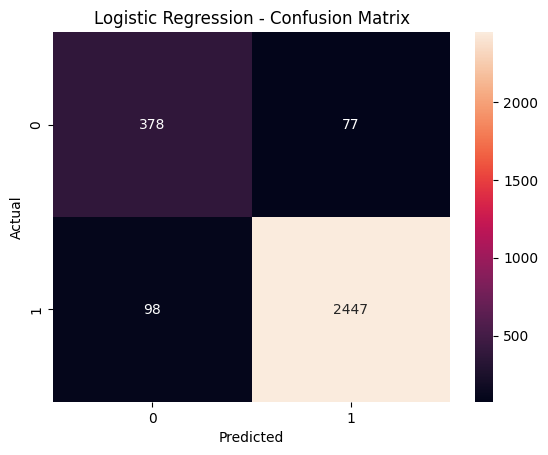

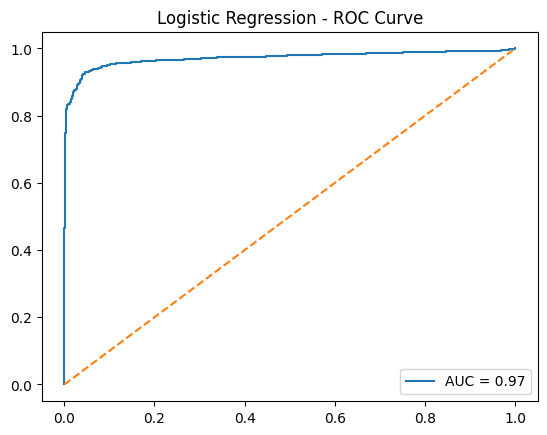

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

evaluate_model_visual(lr, X_test, y_test, "Logistic Regression")


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       455
           1       0.97      0.98      0.98      2545

    accuracy                           0.96      3000
   macro avg       0.92      0.91      0.92      3000
weighted avg       0.96      0.96      0.96      3000



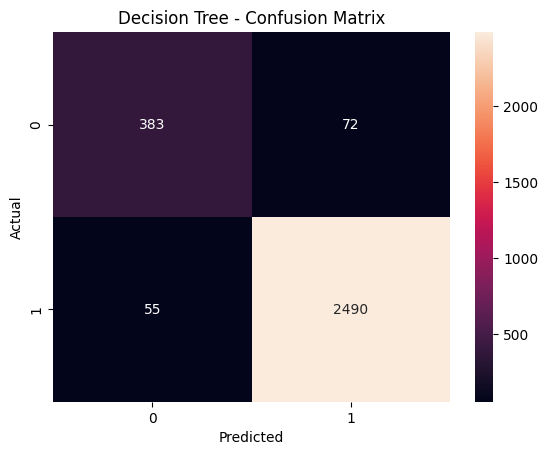

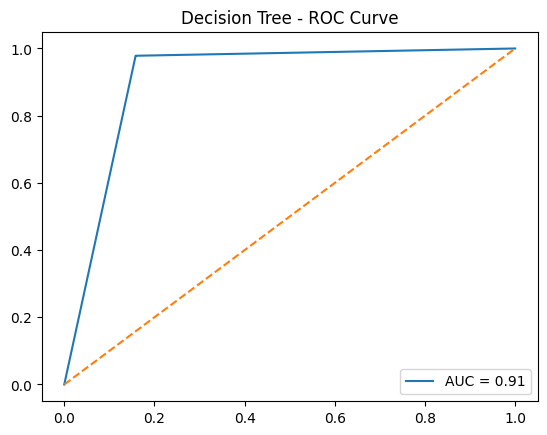

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

evaluate_model_visual(dt, X_test, y_test, "Decision Tree")


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       455
           1       0.99      0.97      0.98      2545

    accuracy                           0.97      3000
   macro avg       0.92      0.96      0.94      3000
weighted avg       0.97      0.97      0.97      3000



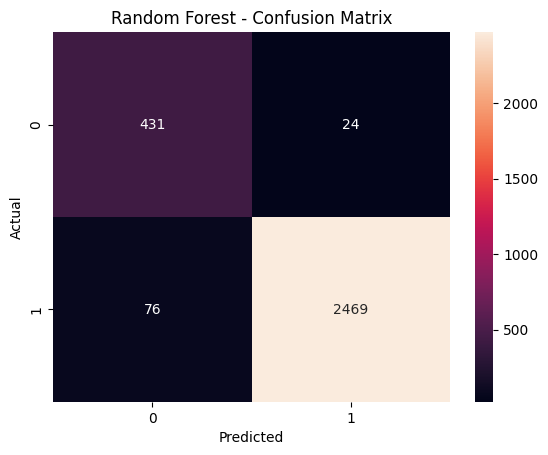

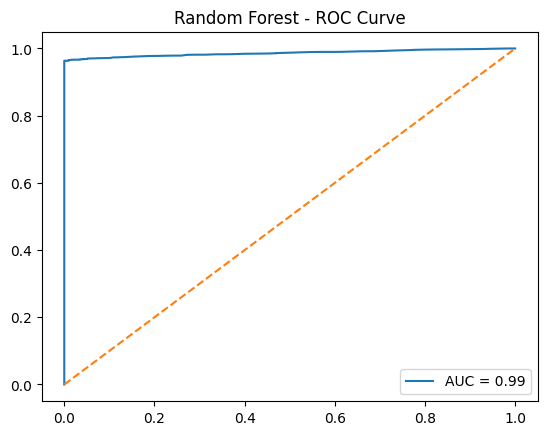

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

evaluate_model_visual(rf, X_test, y_test, "Random Forest")


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       455
           1       0.98      0.97      0.98      2545

    accuracy                           0.96      3000
   macro avg       0.92      0.94      0.93      3000
weighted avg       0.96      0.96      0.96      3000



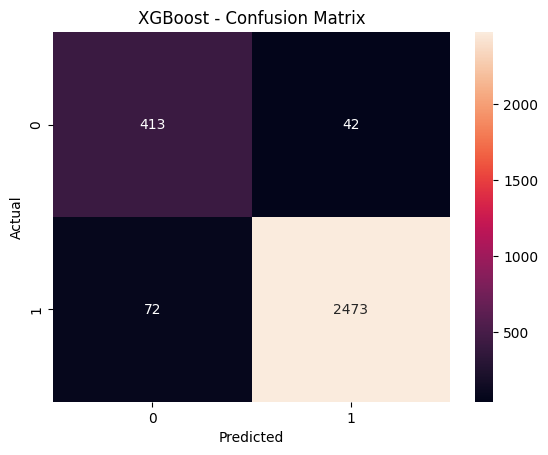

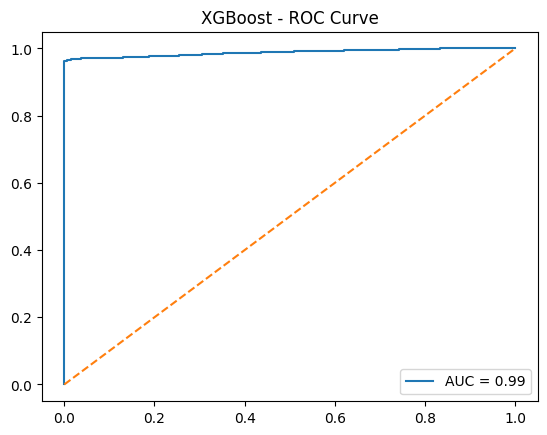

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="logloss")
xgb.fit(X_train, y_train)

evaluate_model_visual(xgb, X_test, y_test, "XGBoost")


===== SVM (SGD) =====
              precision    recall  f1-score   support

           0       0.84      0.67      0.75       455
           1       0.94      0.98      0.96      2545

    accuracy                           0.93      3000
   macro avg       0.89      0.83      0.86      3000
weighted avg       0.93      0.93      0.93      3000



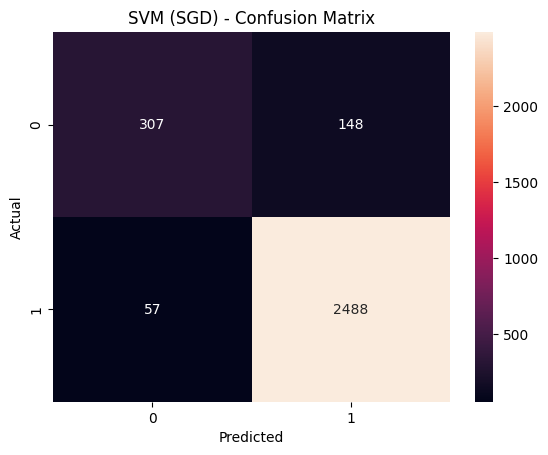

In [11]:
from sklearn.linear_model import SGDClassifier

svm = SGDClassifier(loss="hinge")
svm.fit(X_train, y_train)

evaluate_model_visual(svm, X_test, y_test, "SVM (SGD)")